In [33]:
import pandas as pd

df = pd.read_json(
    "../data/states_2022-06-27-23.json",
)
df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1656370800,ab58b2,31.046356,-82.843700,234.974796,354.975925,0.00000,DAL595,False,False,False,6132.0,10058.40,10660.38,1.656371e+09,1.656371e+09
1,1656370800,406814,43.580246,-71.207055,276.689582,34.546929,0.32512,VIR4C,False,False,False,3056.0,11277.60,11734.80,1.656371e+09,1.656371e+09
2,1656370800,ab2729,40.973831,-74.659180,231.792277,98.166070,-0.97536,AAL1092,False,False,False,7126.0,6111.24,6370.32,1.656371e+09,1.656371e+09
3,1656370800,a4fdb1,30.097977,-81.700433,200.026121,339.840638,0.00000,TMB197,False,False,False,1363.0,11277.60,11925.30,1.656371e+09,1.656371e+09
4,1656370800,c066b0,29.776749,-81.097694,253.161860,183.845054,0.00000,SWG626,False,False,False,6340.0,10972.80,11612.88,1.656371e+09,1.656371e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475776,1656374390,48418b,42.413977,21.748139,256.996575,153.999168,0.00000,KLM44Q,False,False,False,2663.0,11887.20,12390.12,1.656374e+09,1.656374e+09
2475777,1656374390,a19c2e,40.845657,-74.418274,57.620025,179.488444,-2.27584,N20226,False,False,False,1200.0,365.76,373.38,1.656374e+09,1.656374e+09
2475778,1656374390,ab5a01,35.747543,-112.078972,225.901844,240.983416,0.00000,SCX407,False,False,False,3641.0,11574.78,12237.72,1.656374e+09,1.656374e+09
2475779,1656374390,a981c9,43.733414,-81.022190,188.289315,269.686911,4.55168,N711WS,False,False,False,6306.0,6667.50,6797.04,1.656374e+09,1.656374e+09


In [34]:
df.isna().sum()

time                   0
icao24                 0
lat               157438
lon               157438
velocity          222439
heading           222439
vertrate          221613
callsign           65861
onground               0
alert                  0
spi                    0
squawk           1225246
baroaltitude      227249
geoaltitude       294213
lastposupdate     157438
lastcontact            0
dtype: int64

In [35]:
df.isna().any(axis=1).sum()

np.int64(1331275)

In [36]:
df.isna().any(axis=1) / len(df)

0          0.000000e+00
1          0.000000e+00
2          0.000000e+00
3          0.000000e+00
4          0.000000e+00
               ...     
2475776    0.000000e+00
2475777    0.000000e+00
2475778    0.000000e+00
2475779    0.000000e+00
2475780    4.039129e-07
Length: 2475781, dtype: float64

In [37]:
df.dropna(inplace=True)
df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1656370800,ab58b2,31.046356,-82.843700,234.974796,354.975925,0.00000,DAL595,False,False,False,6132.0,10058.40,10660.38,1.656371e+09,1.656371e+09
1,1656370800,406814,43.580246,-71.207055,276.689582,34.546929,0.32512,VIR4C,False,False,False,3056.0,11277.60,11734.80,1.656371e+09,1.656371e+09
2,1656370800,ab2729,40.973831,-74.659180,231.792277,98.166070,-0.97536,AAL1092,False,False,False,7126.0,6111.24,6370.32,1.656371e+09,1.656371e+09
3,1656370800,a4fdb1,30.097977,-81.700433,200.026121,339.840638,0.00000,TMB197,False,False,False,1363.0,11277.60,11925.30,1.656371e+09,1.656371e+09
4,1656370800,c066b0,29.776749,-81.097694,253.161860,183.845054,0.00000,SWG626,False,False,False,6340.0,10972.80,11612.88,1.656371e+09,1.656371e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475775,1656374390,add498,43.229691,-79.347541,171.278952,355.693686,-8.45312,N990WA,False,False,False,3675.0,3627.12,3680.46,1.656374e+09,1.656374e+09
2475776,1656374390,48418b,42.413977,21.748139,256.996575,153.999168,0.00000,KLM44Q,False,False,False,2663.0,11887.20,12390.12,1.656374e+09,1.656374e+09
2475777,1656374390,a19c2e,40.845657,-74.418274,57.620025,179.488444,-2.27584,N20226,False,False,False,1200.0,365.76,373.38,1.656374e+09,1.656374e+09
2475778,1656374390,ab5a01,35.747543,-112.078972,225.901844,240.983416,0.00000,SCX407,False,False,False,3641.0,11574.78,12237.72,1.656374e+09,1.656374e+09


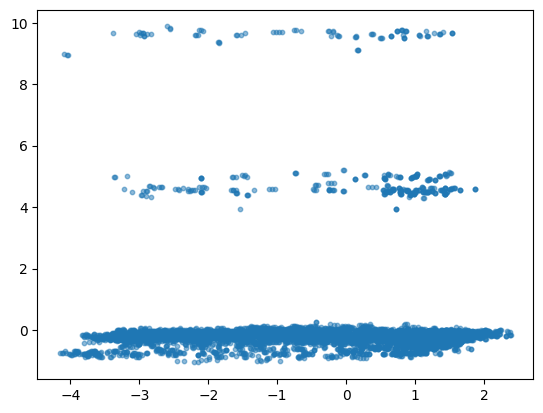

In [22]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

categorical_cols = df.select_dtypes(include="str").columns
numerical_cols = df.select_dtypes(exclude="str").columns

scaler = StandardScaler()
X = scaler.fit_transform(df[numerical_cols])

X = X[:10000]

pca = PCA()
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10)
plt.show()

I0000 00:00:1780400236.362409    6613 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


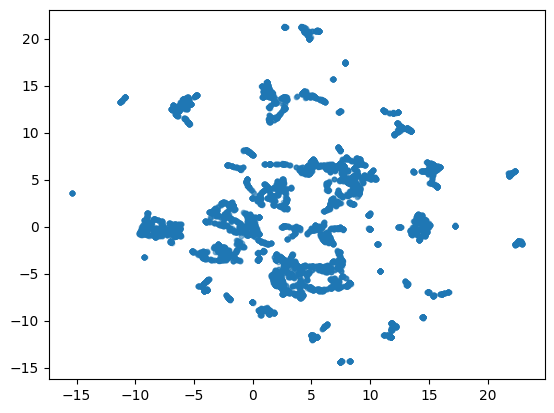

In [23]:
import umap

reducer = umap.UMAP(n_components=2)
X_umap = reducer.fit_transform(X)

plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=10)
plt.show()

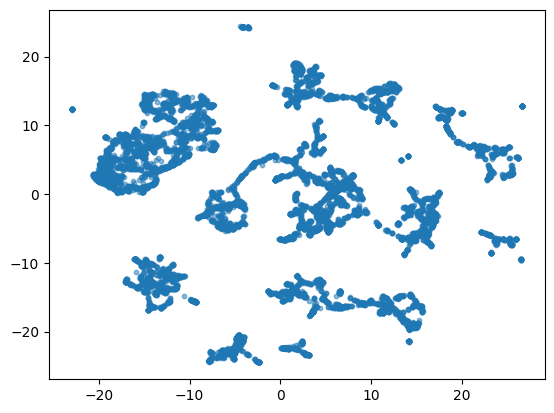

In [24]:
import pacmap

reducer = pacmap.PaCMAP()
X_pacmap = reducer.fit_transform(X)

plt.scatter(X_pacmap[:, 0], X_pacmap[:, 1], alpha=0.5, s=10)
plt.show()

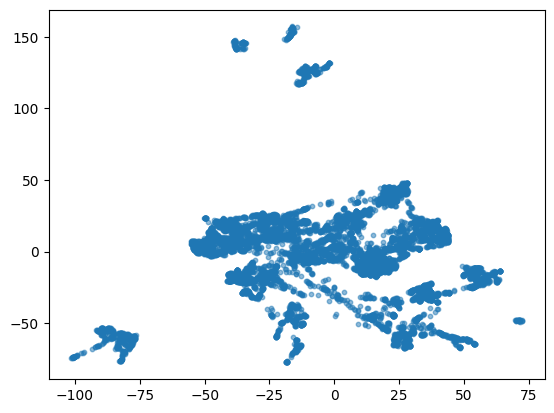

In [25]:
import trimap

reducer = trimap.TRIMAP()
X_trimap = reducer.fit_transform(X)

plt.scatter(X_trimap[:, 0], X_trimap[:, 1], alpha=0.5, s=10)
plt.show()

Will use momentum during exaggeration phase
Computing input similarities...
Using perplexity, so normalizing input data (to prevent numerical problems)
Using perplexity, not the manually set kernel width.  K (number of nearest neighbors) and sigma (bandwidth) parameters are going to be ignored.
Using ANNOY for knn search, with parameters: n_trees 50 and search_k 4500
Going to allocate memory. N: 10000, K: 90, N*K = 900000
Building Annoy tree...
Done building tree. Beginning nearest neighbor search... 
parallel (12 threads):
[===========================================================>] 99% 0.291s
Symmetrizing...
Using the given initialization.
Exaggerating Ps by 12.000000
Input similarities computed (sparsity = 0.011851)!
Learning embedding...
Using FIt-SNE approximation.
Iteration 50 (50 iterations in 0.30 seconds), cost 4.553753
Iteration 100 (50 iterations in 0.32 seconds), cost 3.971061
Iteration 150 (50 iterations in 0.37 seconds), cost 3.847360
Iteration 200 (50 iterations in 0.3

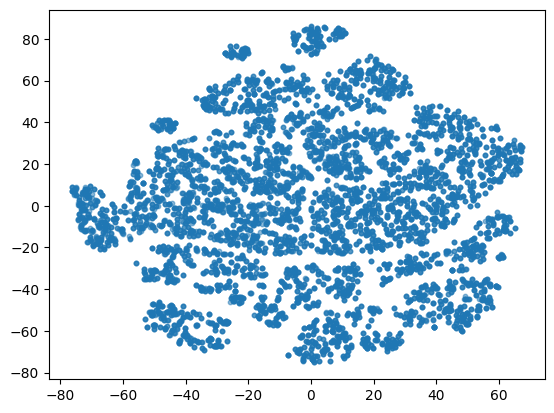

In [26]:
import fitsne
import numpy as np

X_input = np.ascontiguousarray(X, dtype=np.float64)
X_fitsne = fitsne.FItSNE(X_input)

plt.scatter(X_fitsne[:, 0], X_fitsne[:, 1], alpha=0.5, s=10)
plt.show()

In [42]:
df.info()

<class 'pandas.DataFrame'>
Index: 1144506 entries, 0 to 2475779
Data columns (total 16 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   time           1144506 non-null  int64  
 1   icao24         1144506 non-null  str    
 2   lat            1144506 non-null  float64
 3   lon            1144506 non-null  float64
 4   velocity       1144506 non-null  float64
 5   heading        1144506 non-null  float64
 6   vertrate       1144506 non-null  float64
 7   callsign       1144506 non-null  str    
 8   onground       1144506 non-null  bool   
 9   alert          1144506 non-null  bool   
 10  spi            1144506 non-null  bool   
 11  squawk         1144506 non-null  float64
 12  baroaltitude   1144506 non-null  float64
 13  geoaltitude    1144506 non-null  float64
 14  lastposupdate  1144506 non-null  float64
 15  lastcontact    1144506 non-null  float64
dtypes: bool(3), float64(10), int64(1), str(2)
memory usage: 125.5 MB


In [64]:
import numpy as np

flights_df = df.groupby(["icao24", "callsign"]).agg(
    alt_mean=("geoaltitude", "mean"),
    alt_max=("geoaltitude", "max"),
    alt_min=("geoaltitude", "min"),
    alt_std=("geoaltitude", "std"),
    alt_range=("geoaltitude", np.ptp),
    #
    vel_mean=("velocity", "mean"),
    vel_max=("velocity", "max"),
    vel_std=("velocity", "std"),
    #
    vert_mean=("vertrate", "mean"),
    vert_max=("vertrate", "max"),
    vert_min=("vertrate", "min"),
    vert_std=("vertrate", "std"),
    #
    heading_mean=("heading", "mean"),
    heading_std=("heading", "std"),
    #
    lat_range=("lat", np.ptp),
    lon_range=("lon", np.ptp),
    #
    measurements_count=("time", "count"),
    time_span=("time", np.ptp),
)
flights_df.reset_index(inplace=True)
flights_df["flight_id"] = flights_df["icao24"] + "/" + flights_df["callsign"]
flights_df.drop(columns=["icao24", "callsign"], inplace=True)
flights_df.set_index("flight_id", inplace=True)
flights_df.fillna(0, inplace=True)

flights_df

,alt_mean,alt_max,alt_min,alt_std,alt_range,vel_mean,vel_max,vel_std,vert_mean,vert_max,vert_min,vert_std,heading_mean,heading_std,lat_range,lon_range,measurements_count,time_span
flight_id,,,,,,,,,,,,,,,,,,
002b0b/SVA7033,11850.479666,11864.34,11841.48,5.081917,22.86,260.261112,266.222658,3.963273,-0.024452,0.65024,-0.97536,0.193621,147.109999,5.359039,6.816577,5.687002,359,3580
0100a7/MSR533,12471.647632,12496.80,12443.46,8.500453,53.34,265.980523,269.707049,1.417178,-0.099619,1.30048,-1.30048,0.409628,137.209762,1.268626,5.914974,6.924877,359,3580
0100de/MSR627,11925.300000,11925.30,11925.30,0.000000,0.00,272.059175,272.059175,0.000000,0.000000,0.00000,0.00000,0.000000,36.154821,0.000000,0.000000,0.000000,6,50
01013d/MSR986,9746.897222,9906.00,7978.14,408.798312,1927.86,274.178489,282.875911,7.479927,0.845914,6.82752,-0.65024,1.950186,67.648783,6.356267,1.609339,5.704395,216,2150
010154/MSR996,11441.078524,11696.70,10858.50,308.763154,838.20,226.431905,241.613487,6.241775,0.211148,1.95072,-0.97536,0.562323,129.481031,4.713196,3.488070,7.444928,271,2710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
e4926b/AZU2836,1153.668000,1508.76,1059.18,157.622020,449.58,66.696761,90.787342,10.273664,-3.193401,-0.65024,-4.55168,0.747483,127.085794,4.194180,0.059494,0.086721,45,440
e80247/LAN462,9467.975211,11193.78,2331.72,2497.316483,8862.06,177.667415,187.198955,8.560176,4.023551,22.75840,-0.65024,5.474921,272.474229,7.014046,0.165493,3.496342,213,2120
e80452/LAN705,10598.556400,10614.66,10591.80,6.213556,22.86,243.207878,244.551441,0.979718,-0.039014,0.00000,-0.32512,0.106005,256.353725,0.645413,0.612256,3.225968,150,1490


In [65]:
flights_df.describe()

,alt_mean,alt_max,alt_min,alt_std,alt_range,vel_mean,vel_max,vel_std,vert_mean,vert_max,vert_min,vert_std,heading_mean,heading_std,lat_range,lon_range,measurements_count,time_span
count,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000,5763.000000
mean,6787.849145,8802.633784,4030.773732,1496.433969,4771.860052,177.194956,206.164615,22.532756,-0.774535,5.217660,-7.085957,2.813683,181.436996,37.181845,1.743648,3.001086,198.595523,1998.842617
std,4081.501732,4491.473766,4560.720138,1459.819644,4641.994987,64.819220,63.778661,20.288671,3.918752,7.311391,7.897955,2.055306,87.795039,42.398351,1.740743,3.024408,112.667869,1138.418310
min,-22.860000,-22.860000,-53.340000,0.000000,0.000000,0.332294,5.246320,0.000000,-13.794377,-11.704320,-113.792000,0.000000,0.368016,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2967.374242,5715.000000,198.120000,166.728833,617.220000,132.080416,182.250454,4.844189,-3.629073,0.325120,-12.679680,1.118436,106.578443,4.483068,0.372220,0.528186,101.000000,1000.000000
50%,7265.977640,10591.800000,1508.760000,1040.770134,3581.400000,193.615368,227.608189,15.822954,-0.325120,1.300480,-5.527040,2.805602,181.452125,16.096215,1.150259,1.867787,189.000000,1910.000000
75%,10655.185209,11696.700000,8534.400000,2646.700597,8656.320000,227.313001,249.153201,37.517624,0.306418,8.778240,-0.650240,4.145142,255.759888,64.269244,2.592313,4.735182,306.000000,3140.000000
max,20979.536825,39006.780000,20558.760000,12415.065923,38450.520000,301.713771,379.772582,95.420513,18.216880,101.762560,16.906240,30.211566,359.034038,182.265596,8.580624,14.776103,360.000000,3590.000000


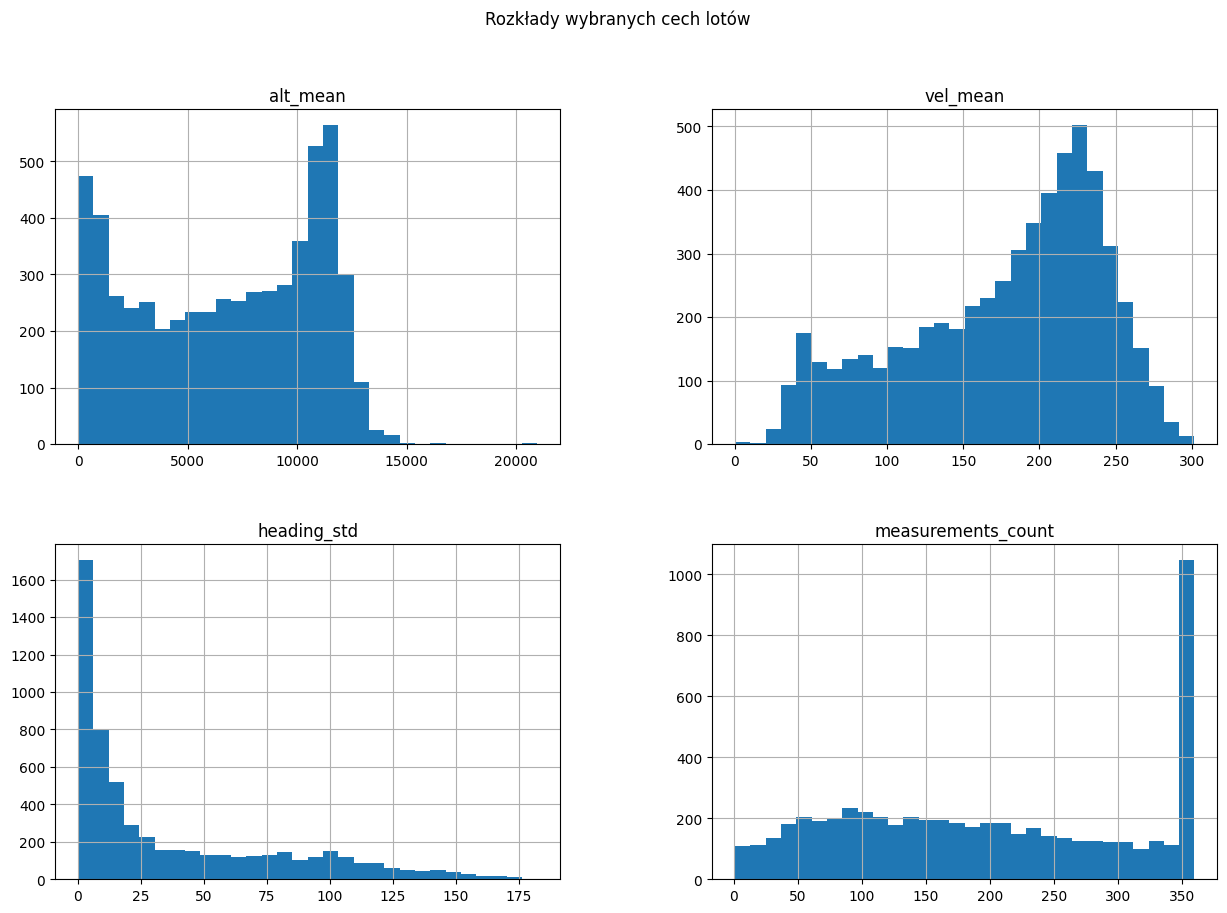

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_plot = ["alt_mean", "vel_mean", "heading_std", "measurements_count"]
flights_df[cols_to_plot].hist(bins=30, figsize=(15, 10))
plt.suptitle("Rozkłady wybranych cech lotów")
plt.show()

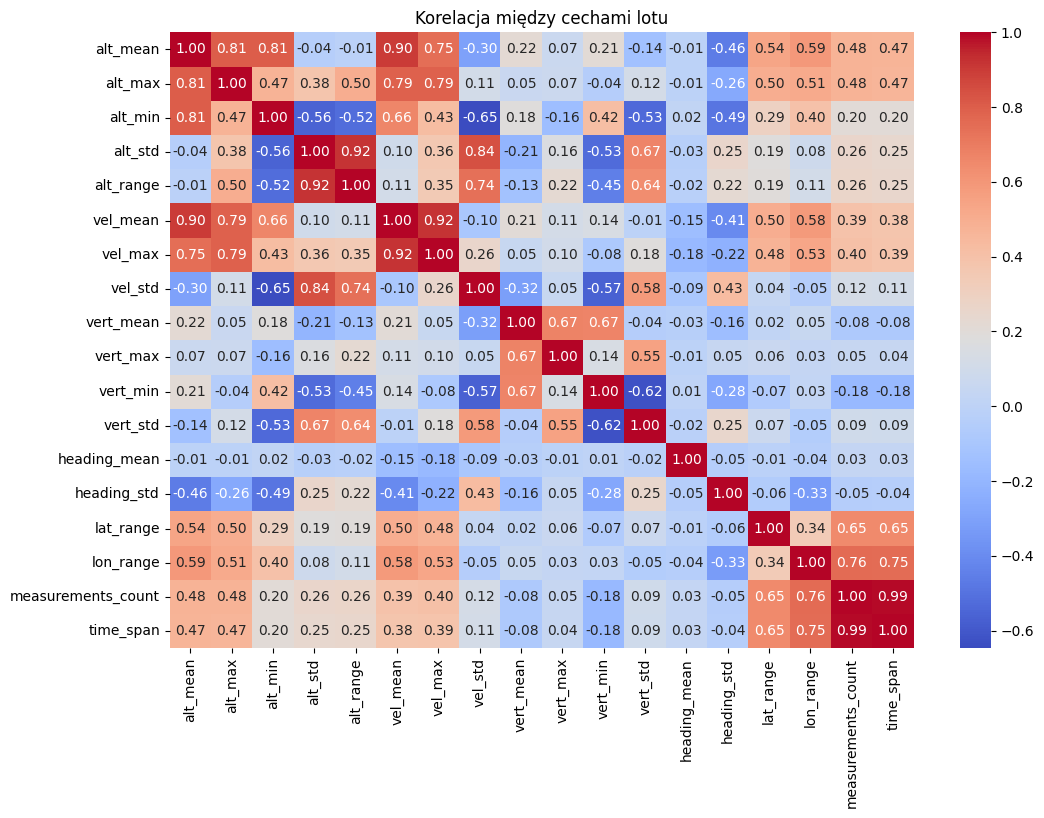

In [67]:
plt.figure(figsize=(12, 8))
sns.heatmap(flights_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelacja między cechami lotu")
plt.show()

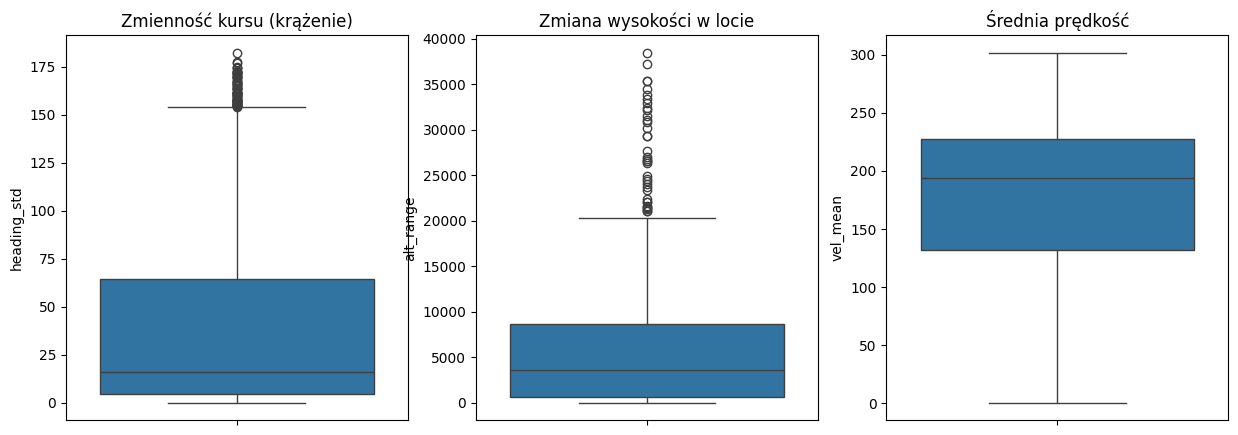

In [68]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=flights_df["heading_std"])
plt.title("Zmienność kursu (krążenie)")

plt.subplot(1, 3, 2)
sns.boxplot(y=flights_df["alt_range"])
plt.title("Zmiana wysokości w locie")

plt.subplot(1, 3, 3)
sns.boxplot(y=flights_df["vel_mean"])
plt.title("Średnia prędkość")
plt.show()

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

scaler_flights = StandardScaler()
X_flights_scaled = scaler_flights.fit_transform(flights_df)

contamination_rate = 0.05

iso_forest = IsolationForest(contamination=contamination_rate, random_state=42)
lof = LocalOutlierFactor(contamination=contamination_rate)
oc_svm = OneClassSVM(nu=contamination_rate)

flights_df["anomaly_IsoForest"] = iso_forest.fit_predict(X_flights_scaled)
flights_df["anomaly_LOF"] = lof.fit_predict(X_flights_scaled)
flights_df["anomaly_SVM"] = oc_svm.fit_predict(X_flights_scaled)

print("Liczba wykrytych anomalii (-1 to anomalia):")
print("\nIsolation Forest:")
print(flights_df["anomaly_IsoForest"].value_counts())

print("\nLocal Outlier Factor:")
print(flights_df["anomaly_LOF"].value_counts())

print("\nOne-Class SVM:")
print(flights_df["anomaly_SVM"].value_counts())

Liczba wykrytych anomalii (-1 to anomalia):

Isolation Forest:
anomaly_IsoForest
 1    5474
-1     289
Name: count, dtype: int64

Local Outlier Factor:
anomaly_LOF
 1    5474
-1     289
Name: count, dtype: int64

One-Class SVM:
anomaly_SVM
 1    5471
-1     292
Name: count, dtype: int64
